#### 還抓得到耶
!wget https://www.dropbox.com/s/l2ul3upj7dkv4ou/synthetic-data.zip

In [45]:
import transformers
print(transformers.__version__)

4.52.4


In [46]:
%reload_ext autoreload
%autoreload 2
from torch_snippets_local import stem, Glob
import configparser, os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import pandas as pd
from PIL import Image
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [47]:
config = configparser.ConfigParser()
config.read('config.ini')
# Load parameters from config file
#root = '/Users/leonjye/Documents/MachineLearingData'
root = config.get('DEFAULT', 'root_dir')
image_folder = os.path.join(root, 'synthetic-data')
images = Glob(os.path.join(image_folder, '*.png'))

found 25132 files in /Users/leonjye/Documents/MachineLearingData/synthetic-data/*.png


In [48]:
# fname2label會把最後一個 os路徑的 / 到 @ 之前的字串當作label
stem_file = lambda x: os.path.splitext(os.path.basename(x))[0]
fname2label = lambda fname: stem_file(fname).split('@')[0]

In [49]:
images_list = []
labels_list = []
for image in images:
  images_list.append(str(image).split('/')[-1])
  labels_list.append(fname2label(image))
df = pd.DataFrame([images_list[:5000], labels_list[:5000]]).T
df.columns = ['file_name', 'text']
df.sample(10)

,file_name,text
1501,nice@hwjNy5.png,nice
2586,save@mQStWf.png,save
2653,hit@zKE7y2.png,hit
1055,industry@xSQUJn.png,industry
705,per@3Q6OoZ.png,per
106,several@SH1Bai.png,several
589,Republican@vM2H9F.png,Republican
2468,military@kun3Zr.png,military
2413,already@IPyViz.png,already
1600,floor@pQbvlO.png,floor


In [50]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [51]:
class IAMDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df['file_name'][idx]
        text = self.df['text'][idx]
        # prepare image (i.e. resize + normalize)
        image = Image.open(os.path.join(self.root_dir, file_name)).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length).input_ids
        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

In [52]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten", use_fast=True)

In [ ]:
train_dataset = IAMDataset(root_dir=image_folder, df=train_df, processor=processor)
eval_dataset = IAMDataset(root_dir=image_folder, df=test_df, processor=processor)

In [ ]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))

Number of training examples: 4500
Number of validation examples: 500


In [ ]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)

pixel_values torch.Size([3, 384, 384])
labels torch.Size([128])


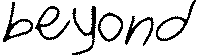

In [ ]:
image = Image.open(os.path.join(image_folder, train_df['file_name'][0])).convert("RGB")
image

In [ ]:
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
'label_str =', label_str

('label_str =', 'beyond')

In [ ]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-stage1 and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [ ]:
for name, param in model.named_parameters():
    param.requires_grad = True
    #print(name)
    # if name=='decoder.output_projection.weight':
    #     param.requires_grad = True


In [ ]:
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

In [ ]:
from transformers import Seq2SeqTrainingArguments
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    eval_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=False, # set to True if you have a GPU with compute capability >= 7.0
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=100,
    num_train_epochs = 10
)

原本的寫法

    import datasets
    cer_metric = datasets.load_metric("cer")

已經被棄用，改成以下的寫法
但要另外安裝
pip install evaluate
pip install jiwer

In [ ]:
import evaluate

cer_metric = evaluate.load("cer")

In [ ]:
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

In [ ]:
from transformers import default_data_collator
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer
# instantiate trainer
trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
)
trainer.train()

/Users/leonjye/Documents/PythonProjects/CompVision2025/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# Load and preprocess the image
image = Image.open(os.path.join(image_folder, "American@3WPOqS.png")).convert("RGB")
pixel_values = processor(image, return_tensors="pt").pixel_values

# Perform inference
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    generated_ids = model.generate(pixel_values.to(device))

# Decode the generated ids to text
predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Predicted Text:", predicted_text)